In [1]:
import control as ctrl
import matplotlib.pyplot as plt
import math
import numpy as np

## Parte A

In [2]:
#Ej b
G = ctrl.TransferFunction([0.25], [0.003,0.0515,0.2,0.0])

gm, pm, wg, wp = ctrl.margin(G)
gm_db = 20 * math.log10(gm)

print(f"Margen de Ganancia: {gm_db:.2f} dB en w = {wg:.2f} rad/s")
print(f"Margen de Fase: {pm:.2f} grados en w = {wp:.2f} rad/s")

Margen de Ganancia: 22.76 dB en w = 8.16 rad/s
Margen de Fase: 72.22 grados en w = 1.22 rad/s


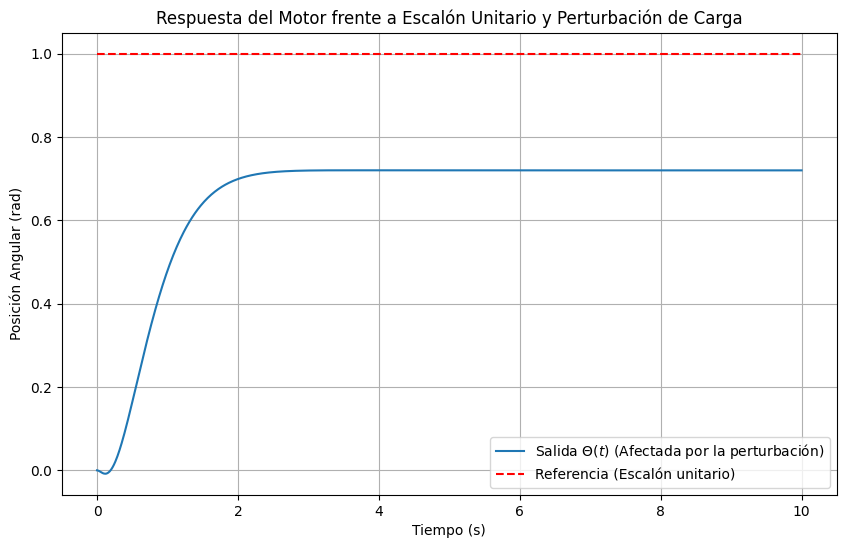

In [3]:
#Ej c
G_pert = ctrl.tf([0.15,0.7],[0.003,0.0515,0.2,0.25])
G_ref = ctrl.tf([0.25],[0.003,0.0515,0.2,0.25])

t=np.linspace(0,10,1000)

t,y_ref = ctrl.step_response(G_ref, T=t)

t,y_pert_step = ctrl.step_response(G_pert, T= t)
y_pert = -0.1 * y_pert_step

y_total = y_pert + y_ref

plt.figure(figsize=(10, 6))

plt.plot(t,y_total,label="Salida $\\Theta(t)$ (Afectada por la perturbación)")
plt.plot(t,np.ones_like(t),'--', label='Referencia (Escalón unitario)', color='red')

plt.title('Respuesta del Motor frente a Escalón Unitario y Perturbación de Carga')
plt.xlabel('Tiempo (s)')
plt.ylabel('Posición Angular (rad)')
plt.legend()
plt.grid(True)
plt.show()

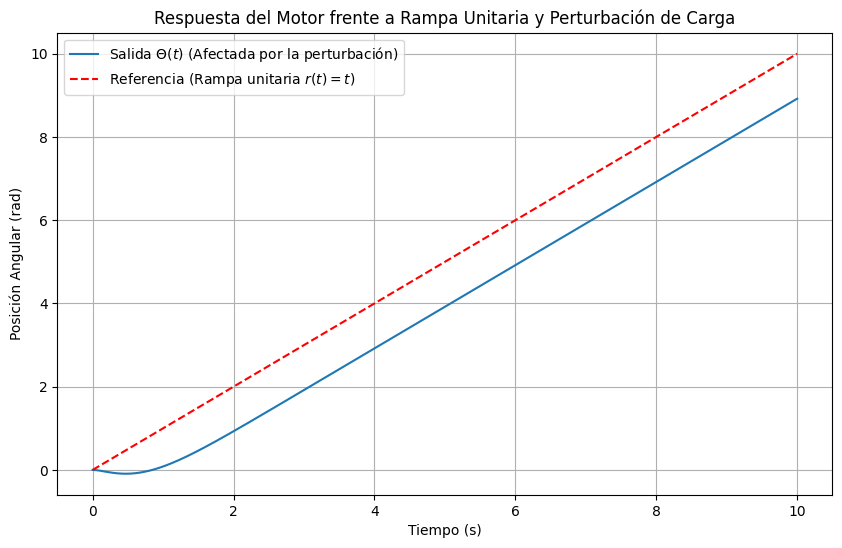

In [4]:
#Ej d
G_pert = ctrl.tf([0.15,0.7],[0.003,0.0515,0.2,0.25])
G_ref = ctrl.tf([0.25],[0.003,0.0515,0.2,0.25])

t=np.linspace(0,10,1000)

t,y_ref = ctrl.forced_response(G_ref, T=t,U=t)

t,y_pert_step = ctrl.step_response(G_pert, T= t)
y_pert = -0.1 * y_pert_step
y_total = y_pert + y_ref

plt.figure(figsize=(10, 6))

plt.plot(t,y_total,label="Salida $\\Theta(t)$ (Afectada por la perturbación)")
plt.plot(t, t, '--', label='Referencia (Rampa unitaria $r(t)=t$)', color='red')

plt.title('Respuesta del Motor frente a Rampa Unitaria y Perturbación de Carga')
plt.xlabel('Tiempo (s)')
plt.ylabel('Posición Angular (rad)')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
G_ref = ctrl.tf([0.25], [0.003, 0.0515, 0.2, 0.25])

# Forzamos a que el cálculo sea al 2% (0.02)
info = ctrl.step_info(G_ref, SettlingTimeThreshold=0.02)

ts = info['SettlingTime']
mp = info['Overshoot']

print(f"VALORES DEL SISTEMA SIN COMPENSAR:")
print(f"Tiempo de establecimiento (ts al 2%): {ts:.2f} s")
print(f"Sobrepico (Mp): {mp:.2f} %")

VALORES DEL SISTEMA SIN COMPENSAR:
Tiempo de establecimiento (ts al 2%): 2.05 s
Sobrepico (Mp): 0.00 %


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


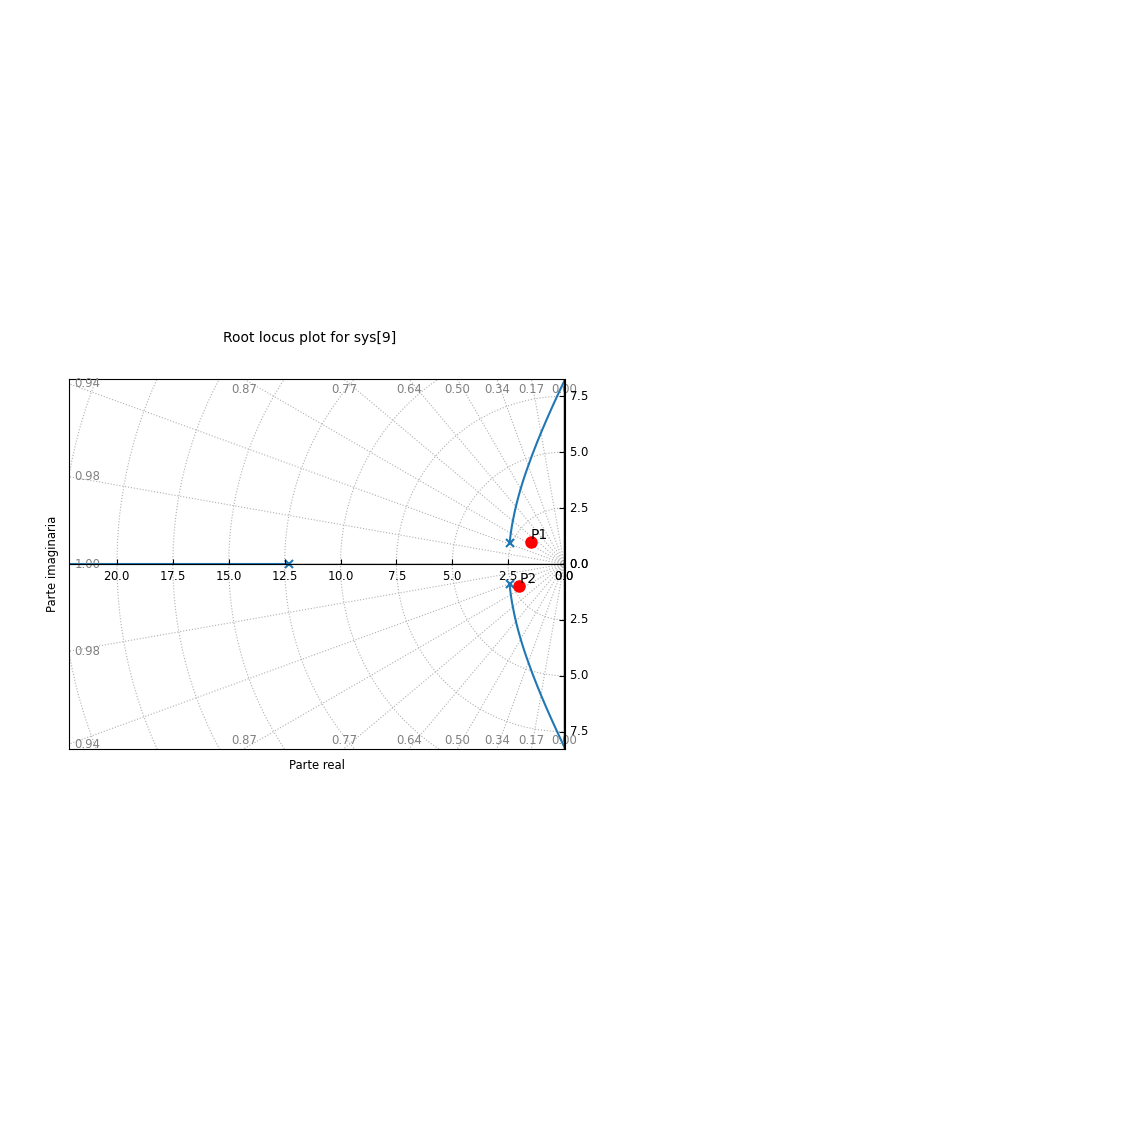

In [ ]:
G_ref = ctrl.tf([0.25], [0.003, 0.0515, 0.2, 0.25])
ctrl.root_locus(G_ref)
plt.plot(-1.5 , 1.0 , "ro" , markersize =8)
plt.plot(-2.0 , -1.0 , "ro" , markersize =8)
plt.text(-1.5 , 1.0 , "P1" , va = "bottom")
plt.text( -2.0 , -1.0 , "P2" , va = "bottom")
plt.xlabel( "Parte real") ; plt . ylabel ("Parte imaginaria")
plt.grid( True )
plt.show()